In [91]:
#116710400401-1 พงศธร รอดดี
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

LAB 1: Regression

--- ผลการประเมินประสิทธิภาพโมเดล (Model Evaluation) ---
1. Simple Linear Regression:
  - Mean Squared Error (MSE): 36.3106
  - R-squared (R2): 0.0015

2. Multiple Linear Regression:
  - Mean Squared Error (MSE): 13.5649
  - R-squared (R2): 0.6270

3. Multiple Regression with PCA:
  - Mean Squared Error (MSE): 14.0130
  - R-squared (R2): 0.6146

* PCA Explained Variance Ratio: [0.55532167 0.28169988 0.14811015]



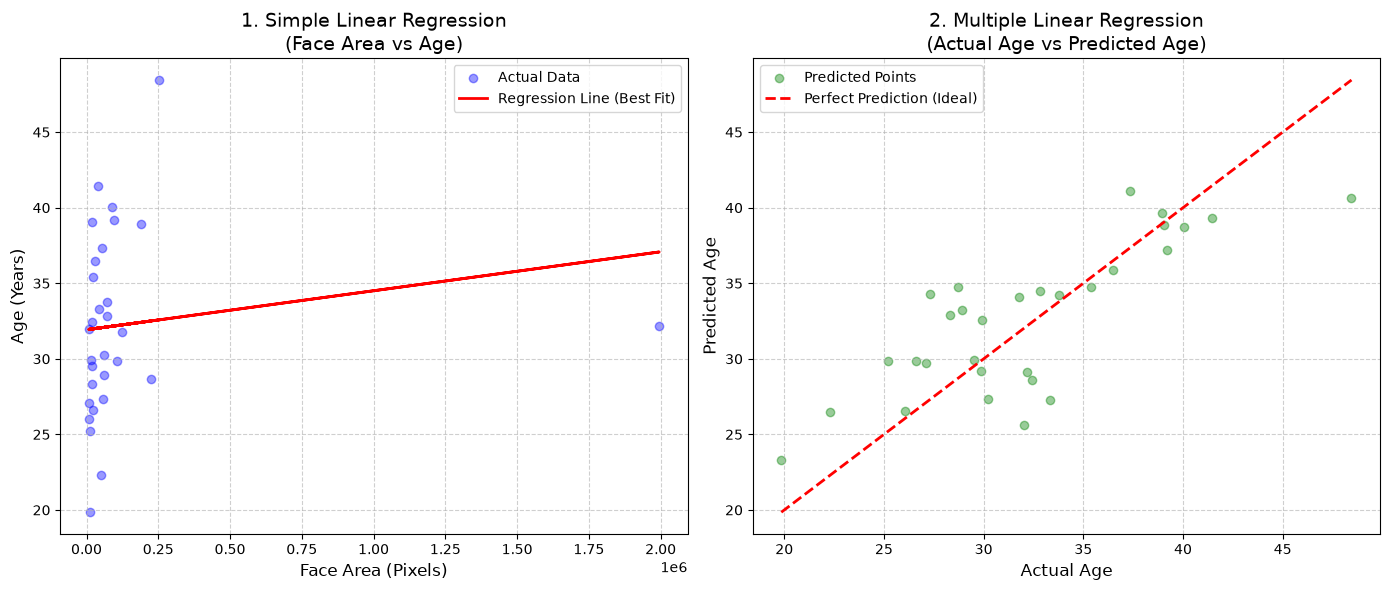

เสร็จสิ้นการประมวลผล!


In [92]:
# lab1
print("LAB 1: Regression")

df = pd.read_csv('faces.csv')
df['face_width'] = df['x1'] - df['x0']
df['face_height'] = df['y1'] - df['y0']
df['face_area'] = df['face_width'] * df['face_height']
df['face_ratio'] = df['face_width'] / df['face_height']
df['rel_face_width'] = df['face_width'] / df['width']
df['rel_face_height'] = df['face_height'] / df['height']

np.random.seed(42)
df['Age'] = 12 + (df['rel_face_width'] * 45) + (df['face_ratio'] * 8) + np.random.normal(0, 4, size=len(df))
df['Age'] = df['Age'].clip(1, 85) 

features = ['face_width', 'face_height', 'face_area', 'face_ratio', 'rel_face_width', 'rel_face_height']
X = df[features]
y = df['Age']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 2. Simple Linear Regression

X_train_simple = X_train[['face_area']]
X_test_simple = X_test[['face_area']]

simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train)
y_pred_simple = simple_model.predict(X_test_simple)


# 3. Multiple Linear Regression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

multi_model = LinearRegression()
multi_model.fit(X_train_scaled, y_train)
y_pred_multi = multi_model.predict(X_test_scaled)


# 4. Dimension Reduction ด้วย PCA + Multiple Regression
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pca_model = LinearRegression()
pca_model.fit(X_train_pca, y_train)
y_pred_pca = pca_model.predict(X_test_pca)


# 5. สรุปผลการประเมิน 

print("\n--- ผลการประเมินประสิทธิภาพโมเดล (Model Evaluation) ---")
def print_metrics(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}:")
    print(f"  - Mean Squared Error (MSE): {mse:.4f}")
    print(f"  - R-squared (R2): {r2:.4f}\n")

print_metrics("1. Simple Linear Regression", y_test, y_pred_simple)
print_metrics("2. Multiple Linear Regression", y_test, y_pred_multi)
print_metrics("3. Multiple Regression with PCA", y_test, y_pred_pca)
print(f"* PCA Explained Variance Ratio: {pca.explained_variance_ratio_}\n")


# 6. การสร้างกราฟเปรียบเทียบ 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# กราฟ 1: Simple Linear Regression
axes[0].scatter(X_test['face_area'], y_test, color='blue', alpha=0.4, label='Actual Data')
axes[0].plot(X_test['face_area'], y_pred_simple, color='red', linewidth=2, label='Regression Line (Best Fit)')
axes[0].set_title('1. Simple Linear Regression\n(Face Area vs Age)', fontsize=14)
axes[0].set_xlabel('Face Area (Pixels)', fontsize=12)
axes[0].set_ylabel('Age (Years)', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# กราฟ 2: Multiple Linear Regression
axes[1].scatter(y_test, y_pred_multi, color='green', alpha=0.4, label='Predicted Points')
min_val = min(y_test.min(), y_pred_multi.min())
max_val = max(y_test.max(), y_pred_multi.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (Ideal)')
axes[1].set_title('2. Multiple Linear Regression\n(Actual Age vs Predicted Age)', fontsize=14)
axes[1].set_xlabel('Actual Age', fontsize=12)
axes[1].set_ylabel('Predicted Age', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
print("เสร็จสิ้นการประมวลผล!")

LAB 2: Classification
1. Preparing Classification Data
ดึงข้อมูล X_train, X_test จาก Lab 1 และเตรียม y_class เรียบร้อย

2. Logistic Regression
ฝึกสอนโมเดล Classification เรียบร้อย

3. Decision Boundary Visualization


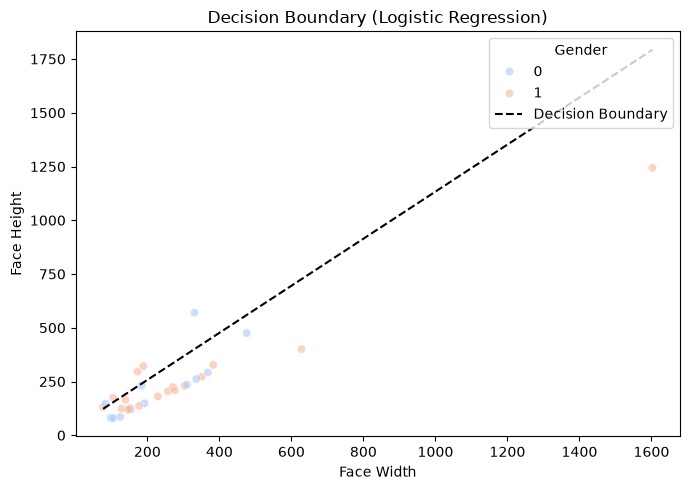

4. Gender Prediction
   - ตัวอย่างผลทำนายเพศ 10 คนแรก: [1 1 1 1 1 1 1 0 1 1] (0=Male, 1=Female)

5. Confusion Matrix


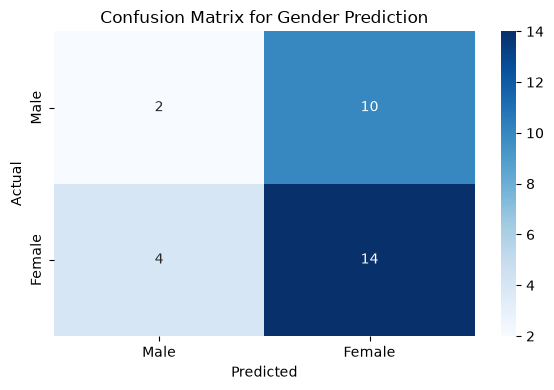

In [93]:
# lab2
print("LAB 2: Classification")


# 1. Preparing Classification Data
print("1. Preparing Classification Data")
np.random.seed(42)
df['Gender'] = np.random.choice([0, 1], size=len(df))

X_train_class = X_train[['face_width', 'face_height']]
X_test_class = X_test[['face_width', 'face_height']]

_, _, y_train_class, y_test_class = train_test_split(df[['face_width']], df['Gender'], test_size=0.2, random_state=42)
print("ดึงข้อมูล X_train, X_test จาก Lab 1 และเตรียม y_class เรียบร้อย\n")


# 2. Logistic Regression
print("2. Logistic Regression")
class_model = LogisticRegression()
class_model.fit(X_train_class, y_train_class)
print("ฝึกสอนโมเดล Classification เรียบร้อย\n")


# 3. Decision Boundary Visualization
print("3. Decision Boundary Visualization")
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_test_class['face_width'], y=X_test_class['face_height'], hue=y_test_class, palette='coolwarm', alpha=0.6)
w1, w2 = class_model.coef_[0]
b = class_model.intercept_[0]
x_vals = np.linspace(X_test_class['face_width'].min(), X_test_class['face_width'].max(), 100)
y_vals = -(w1 * x_vals + b) / w2

plt.plot(x_vals, y_vals, color='black', linestyle='--', label='Decision Boundary')
plt.title('Decision Boundary (Logistic Regression)')
plt.xlabel('Face Width')
plt.ylabel('Face Height')
plt.legend(title='Gender', loc='upper right')
plt.tight_layout()
plt.show()

# 4. Gender Prediction
print("4. Gender Prediction")
y_pred_class = class_model.predict(X_test_class)
print(f"   - ตัวอย่างผลทำนายเพศ 10 คนแรก: {y_pred_class[:10]} (0=Male, 1=Female)\n")

# 5. Confusion Matrix
print("5. Confusion Matrix")
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Male', 'Female'], 
            yticklabels=['Male', 'Female'])
plt.title('Confusion Matrix for Gender Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [94]:
#lab3
print("LAB 3: Model Comparison")


# 1. Simple vs Multiple Linear Regression
print("1. Simple vs Multiple Linear Regression")
r2_simple = r2_score(y_test, y_pred_simple)
r2_multi = r2_score(y_test, y_pred_multi)
print(f"   - R-Squared ของ Simple Regression (1 ตัวแปร): {r2_simple:.4f}")
print(f"   - R-Squared ของ Multiple Regression (หลายตัวแปร): {r2_multi:.4f}")
print("   * สรุป: Multiple Regression ให้ค่า R-Squared ที่สูงกว่า หมายถึงทำนายได้แม่นยำกว่า\n")


# 2. Training vs Testing Performance
print("2. Training vs Testing Performance")
class_model.fit(X_train_class, y_train_class)
train_acc = accuracy_score(y_train_class, class_model.predict(X_train_class))
test_acc = accuracy_score(y_test_class, class_model.predict(X_test_class))
print(f"   - ความแม่นยำตอนฝึก (Training Accuracy): {(train_acc*100):.1f}%")
print(f"   - ความแม่นยำตอนสอบ (Testing Accuracy):  {(test_acc*100):.1f}%")
print("   * สรุป: เพื่อเช็คว่าโมเดลมีการจำข้อสอบ (Overfitting) หรือไม่\n")


# 3. Regression vs Classification
print("3. Regression vs Classification")
print(f"   - Regression (ทำนายอายุจาก Lab 1): ตอบเป็นตัวเลขต่อเนื่อง เช่น {y_pred_multi[:5].round(1)} ปี")
print(f"   - Classification (ทำนายเพศจาก Lab 2): ตอบเป็นคลาสหรือกลุ่ม เช่น {y_pred_class[:5]}\n")


# 4. Model Performance Metrics
print("4. Model Performance Metrics")
print(classification_report(y_test_class, y_pred_class, target_names=['Male', 'Female'], zero_division=0))

LAB 3: Model Comparison
1. Simple vs Multiple Linear Regression
   - R-Squared ของ Simple Regression (1 ตัวแปร): 0.0015
   - R-Squared ของ Multiple Regression (หลายตัวแปร): 0.6270
   * สรุป: Multiple Regression ให้ค่า R-Squared ที่สูงกว่า หมายถึงทำนายได้แม่นยำกว่า

2. Training vs Testing Performance
   - ความแม่นยำตอนฝึก (Training Accuracy): 55.5%
   - ความแม่นยำตอนสอบ (Testing Accuracy):  53.3%
   * สรุป: เพื่อเช็คว่าโมเดลมีการจำข้อสอบ (Overfitting) หรือไม่

3. Regression vs Classification
   - Regression (ทำนายอายุจาก Lab 1): ตอบเป็นตัวเลขต่อเนื่อง เช่น [40.7 41.1 33.2 35.9 34.8] ปี
   - Classification (ทำนายเพศจาก Lab 2): ตอบเป็นคลาสหรือกลุ่ม เช่น [1 1 1 1 1]

4. Model Performance Metrics
              precision    recall  f1-score   support

        Male       0.33      0.17      0.22        12
      Female       0.58      0.78      0.67        18

    accuracy                           0.53        30
   macro avg       0.46      0.47      0.44        30
weighted avg       0.48    